# ISMRMRD to fastMRI-like H5 Converter

This notebook cell provides a function to convert ISMRMRD H5 files into fastMRI-compatible H5 files. It extracts k-space data and XML headers, computes the root-sum-of-squares (RSS) reconstruction, and saves the results in the fastMRI format.

In our original ISMRMRD files, the two main keys are:

- `dataset/data`: Contains the raw k-space data, stored as individual acquisitions.
- `dataset/xml`: Contains the ISMRMRD XML metadata header.

**In fastMRI-style files, these are converted to:**

- `kspace`: A single, standardized array containing all k-space data `[slice, channel, height, width]`).
- `ismrmrd_header`: The XML metadata stored as a string.

In [ ]:
import os
import h5py
import numpy as np
import ismrmrd
import xml.dom.minidom as minidom
from pathlib import Path
import tqdm

# ----------------------- XML helpers -----------------------
import os, h5py, numpy as np, ismrmrd
import xml.dom.minidom as minidom

# ---------------- XML helpers ----------------
def _read_ismrmrd_xml_bytes(ds: ismrmrd.Dataset) -> bytes:
    try:
        xml = ds.read_xml_header()
        return xml.encode("utf-8") if isinstance(xml, str) else xml
    except Exception:
        pass
    try:
        with h5py.File(ds.filename, "r") as f:
            for key in ("ismrmrd_header", "xml", "dataset/xml"):
                if key in f:
                    x = f[key][()]
                    return x if isinstance(x, (bytes, bytearray, np.void)) else str(x).encode("utf-8")
    except Exception:
        pass
    return b""

def _text_of(dom, *path, default=None):
    try:
        nodes = [dom]
        for tag in path:
            nxt = []
            for n in nodes: nxt.extend(n.getElementsByTagName(tag))
            nodes = nxt
            if not nodes: return default
        node = nodes[0]
        return node.firstChild.data.strip() if node.firstChild else default
    except Exception:
        return default

def _hdr_limits(dom):
    """Devuelve (ky_min, ky_max, ky_center, sl_min, sl_max) desde XML si existen."""
    if dom is None: return (None, None, None, None, None)
    def _i(*p):
        t = _text_of(dom, *p)
        try: return int(t) if t is not None else None
        except: return None
    ky_min    = _i("encoding","encodingLimits","kspace_encoding_step_1","minimum")
    ky_max    = _i("encoding","encodingLimits","kspace_encoding_step_1","maximum")
    ky_center = _i("encoding","encodingLimits","kspace_encoding_step_1","center")
    sl_min    = _i("encoding","encodingLimits","slice","minimum")
    sl_max    = _i("encoding","encodingLimits","slice","maximum")
    return ky_min, ky_max, ky_center, sl_min, sl_max

# ---- fastMRI-style centered, unitary 2D FFT/iFFT (NumPy) ----
def fft2c_np(x: np.ndarray) -> np.ndarray:
    # x: (..., H, W) complex
    return np.fft.fftshift(
        np.fft.fft2(np.fft.ifftshift(x, axes=(-2, -1)), axes=(-2, -1), norm="ortho"),
        axes=(-2, -1),
    )

def ifft2c_np(k: np.ndarray) -> np.ndarray:
    # k: (..., H, W) complex
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), axes=(-2, -1), norm="ortho"),
        axes=(-2, -1),
    )

# ---- fastMRI-style Root-Sum-of-Squares over coils ----
def rss_np(coil_imgs: np.ndarray, axis: int = -3) -> np.ndarray:
    # coil_imgs: (..., C, H, W) complex; axis points to C
    return np.sqrt(np.sum(np.abs(coil_imgs) ** 2, axis=axis)).astype(np.float32)

def _padding_from_header(dom, W):
    # intenta con encodedSpace.matrixSize.x o BaseResolution
    Nx = None
    try:
        tx = _text_of(dom, "encoding","encodedSpace","matrixSize","x")
        if tx is not None: Nx = int(tx)
    except: pass
    if Nx is None:
        try:
            br = _text_of(dom, "userParameters","userParameterString","value")  # a veces no viene ordenado
        except: br = None
    # mejor: busca explícitamente BaseResolution en userParameters
    if Nx is None and dom is not None:
        try:
            ups = dom.getElementsByTagName("userParameterString")
            for node in ups:
                nm = _text_of(node, "name")
                if nm == "BaseResolution":
                    Nx = int(_text_of(node, "value"))
                    break
        except: pass
    if Nx is None:
        return None
    Nx = max(1, min(Nx, W))     # acota
    Lh = (W - Nx) // 2
    Rh = Lh + Nx
    return Lh, Rh
# ---------------- Converter -------------------
def ismrmrd_to_fastmri_h5_strict(src_path: str, dst_path: str) -> None:
    ds = ismrmrd.Dataset(src_path, "dataset", create_if_needed=False)

    # XML
    xml_bytes = _read_ismrmrd_xml_bytes(ds)
    dom = None
    if xml_bytes:
        try: dom = minidom.parseString(xml_bytes)
        except Exception: dom = None

    # Dimensiones básicas
    n_acq = ds.number_of_acquisitions()
    if n_acq == 0:
        raise ValueError(f"No acquisitions in: {src_path}")
    acq0 = ds.read_acquisition(0)
    W = int(acq0.number_of_samples)
    C = int(acq0.active_channels)

    # Escanea índices reales para conocer offsets
    uniq_ky, uniq_sl = set(), set()
    for i in range(n_acq):
        a = ds.read_acquisition(i)
        if a.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT) or a.isFlagSet(ismrmrd.ACQ_IS_NAVIGATION_DATA):
            continue
        uniq_ky.add(int(a.idx.kspace_encode_step_1))
        uniq_sl.add(int(a.idx.slice))

    # Offsets y tamaños correctos
    ky_min_real = min(uniq_ky) if uniq_ky else 0
    ky_max_real = max(uniq_ky) if uniq_ky else -1
    sl_min_real = min(uniq_sl) if uniq_sl else 0
    sl_max_real = max(uniq_sl) if uniq_sl else -1

    H = (ky_max_real - ky_min_real + 1) if ky_max_real >= ky_min_real else 1
    S = (sl_max_real - sl_min_real + 1) if sl_max_real >= sl_min_real else 1

    # Centro ky desde header (ajustado por offset)
    ky_min_hdr, ky_max_hdr, ky_center_hdr, sl_min_hdr, sl_max_hdr = _hdr_limits(dom)
    ky_center_hdr_adj = None
    if ky_center_hdr is not None and ky_min_hdr is not None:
        ky_center_hdr_adj = ky_center_hdr - ky_min_hdr  # alinear a nuestro eje [0..H-1]

    # Ensamblado
    kspace = np.zeros((S, C, H, W), dtype=np.complex64)
    hit    = np.zeros((S, H), dtype=np.int32)

    for i in range(n_acq):
        a = ds.read_acquisition(i)
        if a.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT) or a.isFlagSet(ismrmrd.ACQ_IS_NAVIGATION_DATA):
            continue

        sl = int(a.idx.slice)                  # índices crudos del scanner
        ky = int(a.idx.kspace_encode_step_1)

        slw = sl - sl_min_real                 # normaliza a [0..S-1]
        kyw = ky - ky_min_real
        if not (0 <= slw < S and 0 <= kyw < H):
            continue

        data = a.data.astype(np.complex64, copy=False)  # (C,W) o (W,C)
        if data.shape == (W, C):
            data = data.T
        elif data.shape != (C, W):
            tmp = np.zeros((C, W), dtype=np.complex64)
            c = min(C, data.shape[0]); w = min(W, data.shape[1])
            tmp[:c, :w] = data[:c, :w]; data = tmp

        kspace[slw, :, kyw, :] += data
        hit[slw, kyw] += 1

    # Promedia duplicados
    hit_safe = np.where(hit > 0, hit, 1).astype(np.float32)   # (S,H)
    kspace = kspace / hit_safe[:, None, :, None]

    # Centra ky en H//2 (usa header ajustado si estaba)
    def _roll_ky_to_half(k_sc_hw, ky_center_hint=None):
        S, C, H, W = k_sc_hw.shape
        if ky_center_hint is None:
            E = np.abs(k_sc_hw).sum(axis=(1,3))   # (S,H)
            ky_est = int(np.median(E.argmax(axis=1)))
        else:
            ky_est = int(ky_center_hint)
        shift = (H//2 - ky_est) % H
        if shift: k_sc_hw = np.roll(k_sc_hw, shift=shift, axis=2)
        return k_sc_hw, ky_est, shift

    kspace, ky_est, ky_shift = _roll_ky_to_half(kspace, ky_center_hdr_adj)

    # Recon de conveniencia
    coil_imgs = ifft2c_np(kspace)          # (S,C,H,W)
    rss = rss_np(coil_imgs, axis=1)        # (S,H,W)
    # reconSpace (opcional, acotado a H,W reales)
    recon_y, recon_x = H, W
    if dom is not None:
        try:
            ry = _text_of(dom, "encoding","reconSpace","matrixSize","y")
            rx = _text_of(dom, "encoding","reconSpace","matrixSize","x")
            if ry is not None: recon_y = max(1, min(int(ry), H))
            if rx is not None: recon_x = max(1, min(int(rx), W))
        except Exception:
            pass

    # Padding desde header (si existe)
    padL, padR = 0, W
    pad_hdr = _padding_from_header(dom, W)
    if pad_hdr is not None:
        padL, padR = pad_hdr    

    # Escritura
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    with h5py.File(dst_path, "w") as f:
        f.create_dataset("kspace", data=kspace)                       # (S,C,H,W) complejo
        f.create_dataset("reconstruction_rss", data=rss)              # (S,H,W) float32
        f.create_dataset("ismrmrd_header", data=np.void(xml_bytes))

        f.attrs["max"] = rss.max()
        f.attrs["shape_sc_hw"] = np.array([S, C, H, W], dtype=np.int64)
        f.attrs["recon_size"] = np.array([recon_y, recon_x], dtype=np.int64)

        # padding “hasta el final”
        f.attrs["padding_left"]  = np.int64(padL)
        f.attrs["padding_right"] = np.int64(padR)
        f.attrs["padding"]       = np.array([padL, padR], dtype=np.int64)

        f.create_dataset("ky_hits", data=hit.astype(np.int32))

import os
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
from typing import Tuple, Optional
import tqdm

# ---- make sure this is defined above: ismrmrd_to_fastmri_h5_strict(src, dst) ----
# from your_module import ismrmrd_to_fastmri_h5_strict

def _convert_one(arg: Tuple[str, str]) -> Tuple[str, Optional[str]]:
    """Worker: returns (src_path, error_msg_or_None)."""
    src, dst = arg
    try:
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        ismrmrd_to_fastmri_h5_strict(src, dst)
        return (src, None)
    except Exception as e:
        return (src, f"{type(e).__name__}: {e}")
    

def convert_folder_mp(
    src_folder: str,
    dst_folder: str,
    pattern: str = "*.h5",
    max_workers: Optional[int] = None,
    skip_existing: bool = True,
) -> None:
    srcp = Path(src_folder)
    dstp = Path(dst_folder)
    files = sorted(srcp.glob(pattern))

    # Prepare tasks
    tasks = []
    for sp in files:
        dp = dstp / sp.name
        if skip_existing and dp.exists():
            continue
        tasks.append((str(sp), str(dp)))

    if not tasks:
        print("Nothing to do (all done or no matches).")
        return

    if max_workers is None:
        # Good default: number of physical/logical cores, capped a bit
        max_workers = max(1, min(os.cpu_count() or 1, 8))

    print(f"Converting {len(tasks)} files with {max_workers} workers…")
    errors = []

    # h5py is NOT thread-safe → use *processes* (ProcessPoolExecutor)
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_convert_one, t) for t in tasks]
        for fut in tqdm.tqdm(as_completed(futures), total=len(futures), desc="Converting"):
            src, err = fut.result()
            if err:
                errors.append((src, err))

    if errors:
        print("\n=== Errors ===")
        for src, err in errors[:25]:
            print(f"- {src}: {err}")
        if len(errors) > 25:
            print(f"... and {len(errors)-25} more")
    else:
        print("All files converted successfully ✅")

# ---------------- example usage ----------------
if __name__ == "__main__":
    convert_folder_mp(
        src_folder='../../../../../data/datasets/msk_mri_h5/test',
        dst_folder='../../../../../data/datasets/msk_mri_h5/test_varnet',
        pattern="*.h5",
        max_workers=None,     # auto
        skip_existing=True,   # don’t redo work
    )


Converting 429 files with 8 workers…


Converting:   0%|          | 0/429 [00:00<?, ?it/s]

[info] W=512 C=12  S=36 (sl 0..35)  H=336 (ky 0..335)  ky_center_hdr_adj=168
[info] W=640 C=12  S=34 (sl 0..33)  H=384 (ky 0..383)  ky_center_hdr_adj=192
[info] W=768 C=12  S=22 (sl 0..21)  H=585 (ky 0..584)  ky_center_hdr_adj=292
[info] W=640 C=12  S=18 (sl 0..17)  H=516 (ky 0..515)  ky_center_hdr_adj=258
[info] W=640 C=12  S=34 (sl 0..33)  H=414 (ky 1..414)  ky_center_hdr_adj=207
[info] W=640 C=16  S=28 (sl 0..27)  H=479 (ky 0..478)  ky_center_hdr_adj=240
[info] W=640 C=12  S=36 (sl 0..35)  H=438 (ky 1..438)  ky_center_hdr_adj=219
[info] W=768 C=12  S=18 (sl 0..17)  H=486 (ky 0..485)  ky_center_hdr_adj=243


Converting:   0%|          | 0/429 [00:53<?, ?it/s]


In [ ]:
import torch
from fastmri.data import transforms as T
from fastmri.data.subsample import create_mask_for_mask_type
from fastmri.data.transforms import apply_mask, VarNetSample

import torch
from fastmri.data.transforms import VarNetSample, apply_mask
from fastmri.data import transforms as T

class VarNetDataTransformAutoMask(T.VarNetDataTransform):
    """
    Aplica la máscara en el eje correcto automáticamente:
    - Si la máscara estándar funciona sin swap (ky en -2), usa eso.
    - Si no, hace swap H<->W SOLO para enmascarar y vuelve.
    """
    def __call__(self, kspace, mask, target, attrs, fname, slice_num):
        k = torch.as_tensor(kspace)             # (C, H, W, 2)
        acq_start, acq_end = 0, k.shape[-2]
        if "padding" in attrs:
            acq_start = int(attrs["padding"][0])
            acq_end   = int(attrs["padding"][1])

        seed = None
        if self.use_seed:
            seed = tuple(map(ord, fname))

        def _try_apply(kspace_like):
            if self.mask_func is None:
                return kspace_like, None, 0
            try:
                return apply_mask(kspace_like, self.mask_func, seed=seed, padding=(acq_start, acq_end))
            except Exception:
                # cuando padding no cuadra con ese eje, cae aquí
                return None, None, None

        # 1) intentar sin swap (asume ky en -2)
        masked_a, mask_a, nlow_a = _try_apply(k)
        ok_a = (masked_a is not None) and (mask_a is not None) and (mask_a.max() > 0)

        # 2) intentar con swap (C, W, H, 2)
        ks_sw = k.permute(0, 2, 1, 3).contiguous()
        masked_b, mask_b, nlow_b = _try_apply(ks_sw)
        ok_b = (masked_b is not None) and (mask_b is not None) and (mask_b.max() > 0)

        if ok_a and (not ok_b):
            masked_k, mask_t = masked_a, mask_a
        elif ok_b and (not ok_a):
            masked_k, mask_t = masked_b.permute(0, 2, 1, 3).contiguous(), mask_b.permute(0, 2, 1, 3).contiguous()
        elif ok_a and ok_b:
            # elegir la que tenga más cobertura (más 1s)
            if mask_b.sum() > mask_a.sum():
                masked_k, mask_t = masked_b.permute(0, 2, 1, 3).contiguous(), mask_b.permute(0, 2, 1, 3).contiguous()
            else:
                masked_k, mask_t = masked_a, mask_a
        else:
            # último recurso: no aplicar máscara
            masked_k, mask_t, nlow_a = k, None, 0

        # resto igual a VarNetDataTransform
        if "recon_size" in attrs:
            crop_size = (int(attrs["recon_size"][0]), int(attrs["recon_size"][1]))
        else:
            crop_size = (int(k.shape[-3]), int(k.shape[-2]))

        if target is None:
            img = T.ifft2c(masked_k)
            targ = T.complex_abs(img)
            targ = T.center_crop(targ, crop_size)
        else:
            targ = torch.as_tensor(target)

        return VarNetSample(
            masked_kspace=masked_k,
            mask=mask_t,
            num_low_frequencies=nlow_a if ok_a or (not ok_b) else nlow_b,
            target=targ,
            fname=fname,
            slice_num=slice_num,
            max_value=torch.tensor(attrs["max"]) if "max" in attrs else None,
            crop_size=torch.tensor(crop_size),
        )



In [20]:
# read h5 file and get shape of kspace
#filename = '../../../../../data/datasets/msk_mri_h5/test_varnet/meas_MID00033_FID133678_RT_COR_T2_FS_DIXON.h5'
import h5py
filename = "./fast_mri_samples/file1000007.h5"
with h5py.File(filename, 'r') as f:
    kspace = f['kspace']
    recon= f['reconstruction_rss']
    max_value = f.attrs['max']
    print(f'K-space shape: {kspace.shape}')
    print(f'Max value: {max_value}')
    for i in range(kspace.shape[0]):
        print(f'Reconstruction max for slice {i}: {recon[i].max()}')
    print(f'Reconstruction shape: {recon.shape}')

K-space shape: (38, 15, 640, 368)
Max value: 0.0001584038759995007
Reconstruction max for slice 0: 4.9380720156477764e-05
Reconstruction max for slice 1: 5.023234189138748e-05
Reconstruction max for slice 2: 7.458167965523899e-05
Reconstruction max for slice 3: 7.510569412261248e-05
Reconstruction max for slice 4: 8.388459536945447e-05
Reconstruction max for slice 5: 7.195439684437588e-05
Reconstruction max for slice 6: 6.656295590801165e-05
Reconstruction max for slice 7: 6.950234819669276e-05
Reconstruction max for slice 8: 8.5290455899667e-05
Reconstruction max for slice 9: 8.135993994073942e-05
Reconstruction max for slice 10: 8.439994417130947e-05
Reconstruction max for slice 11: 8.568037446821108e-05
Reconstruction max for slice 12: 8.098449325188994e-05
Reconstruction max for slice 13: 8.083520515356213e-05
Reconstruction max for slice 14: 8.361853542737663e-05
Reconstruction max for slice 15: 7.142061076592654e-05
Reconstruction max for slice 16: 7.372051186393946e-05
Reconstru

In [1]:
from fastmri.data import SliceDataset
from fastmri.data.subsample import create_mask_for_mask_type
from fastmri.data import transforms as T
data_path = '../../../../../data/datasets/msk_mri_h5/test_varnet'
#data_path = './fast_mri_samples'
mask_func = create_mask_for_mask_type("equispaced_fraction", [0.08], [2])
data_transform = T.VarNetDataTransform(mask_func=mask_func)
#data_transform = VarNetDataTransformAutoMask(mask_func=mask_func)
dataset = SliceDataset(root=data_path, transform=data_transform, challenge="multicoil")


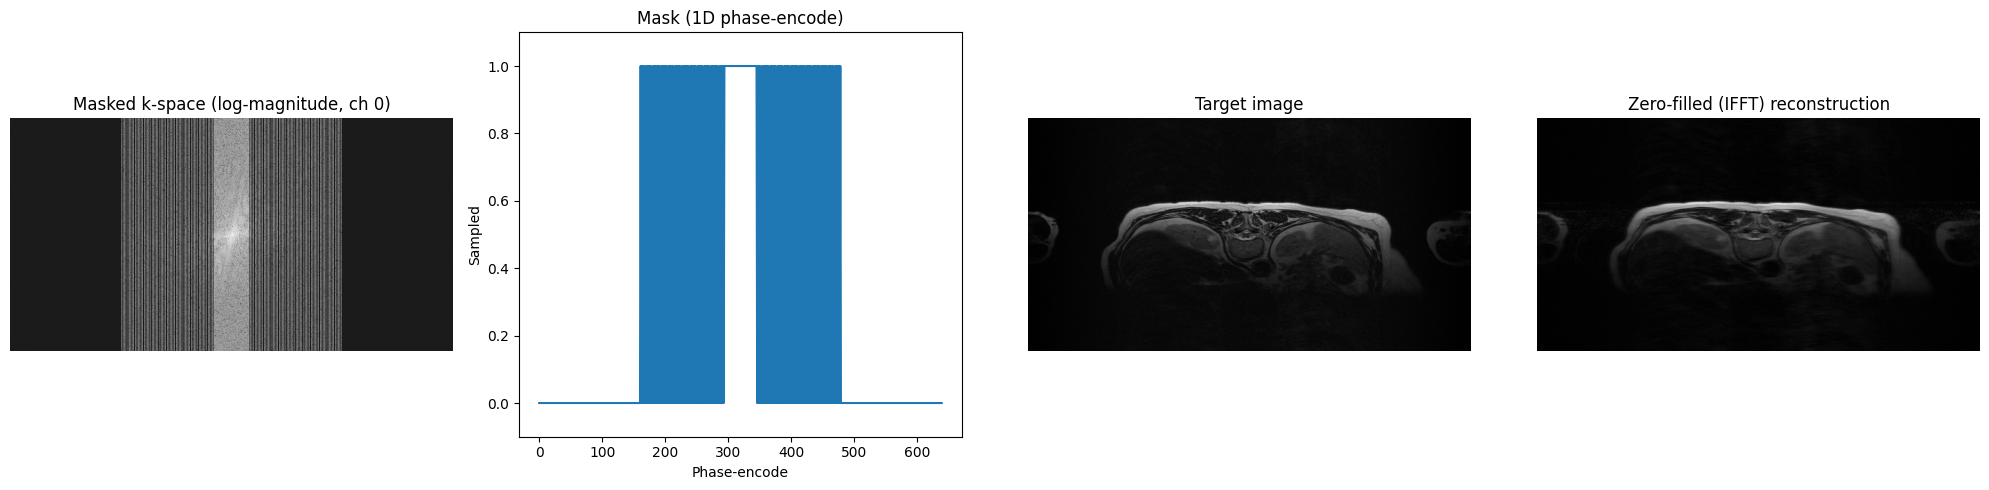

In [8]:
# Plot masked k-space, mask, target image, and zero-filled (IFFT) reconstruction for the first sample
import matplotlib.pyplot as plt
import torch
import numpy as np

#sample = dataset_new_test[58]
#sample= dataset_old_test[504]
sample = dataset[2590]
#sample = dataset[505]
#sample = dataset[100]
masked_kspace = sample.masked_kspace # torch tensor, shape: (num_coils, height, width, 2)
mask = sample.mask.numpy()
target = sample.target.numpy()

# For visualization, take the first channel of masked_kspace and show log-magnitude
masked_kspace_np = masked_kspace.numpy() if hasattr(masked_kspace, 'numpy') else masked_kspace
masked_kspace_mag = np.log(np.abs(masked_kspace_np[0, ..., 0] + 1e-9))

# Zero-filled (IFFT) reconstruction
if masked_kspace.shape[-1] == 2:
    masked_kspace_cplx = torch.view_as_complex(masked_kspace)
else:
    masked_kspace_cplx = masked_kspace
img_coils = torch.fft.ifftshift(torch.fft.ifft2(torch.fft.fftshift(masked_kspace_cplx, dim=(-2, -1)), norm="ortho"), dim=(-2, -1))
img_rss = torch.sqrt((img_coils.abs() ** 2).sum(dim=0))

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(masked_kspace_mag, cmap='gray')
axs[0].set_title('Masked k-space (log-magnitude, ch 0)')
axs[0].axis('off')

# Visualize the 1D mask as a line plot
axs[1].plot(np.squeeze(mask))
axs[1].set_title('Mask (1D phase-encode)')
axs[1].set_ylim(-0.1, 1.1)
axs[1].set_xlabel('Phase-encode')
axs[1].set_ylabel('Sampled')

axs[2].imshow(target, cmap='gray')
axs[2].set_title('Target image')
axs[2].axis('off')

axs[3].imshow(img_rss.numpy(), cmap='gray')
axs[3].set_title('Zero-filled (IFFT) reconstruction')
axs[3].axis('off')

plt.tight_layout()
plt.show()

In [3]:
import h5py, torch, numpy as np
filename = "../../../../../data/datasets/msk_mri_h5/test_varnet/meas_MID00033_FID133678_RT_COR_T2_FS_DIXON.h5"

with h5py.File(filename, "r") as f:
    K = f["kspace"][()]              # (S,C,H,W) complejo
S,C,H,W = K.shape
ks = torch.from_numpy(K[0])

E_ky = torch.abs(ks).sum(dim=(0,2))  # (H,)
E_kx = torch.abs(ks).sum(dim=(0,1))  # (W,)
print("argmax ky, kx:", int(E_ky.argmax()), int(E_kx.argmax()), "expected ~", H//2, W//2)
# Debe imprimir ky ≈ H//2. Si no, dime esos 2 números y lo corregimos.


argmax ky, kx: 238 320 expected ~ 239 320


In [38]:
import h5py, numpy as np

def load_kspace_sc_hw(path):
    with h5py.File(path, "r") as f:
        if "kspace" not in f:
            raise KeyError("No 'kspace' dataset in file.")
        dset = f["kspace"]
        arr = dset[()]  # read to NumPy

    # Case A: compound dtype with fields 'r','i'
    if arr.dtype.names is not None and set(arr.dtype.names) >= {"r","i"}:
        arr = arr["r"].astype(np.float32) + 1j * arr["i"].astype(np.float32)

    # Case B: last-dim real/imag
    if arr.ndim == 5 and arr.shape[-1] == 2:
        arr = arr[..., 0].astype(np.float32) + 1j * arr[..., 1].astype(np.float32)

    # Now expect complex array
    if not np.iscomplexobj(arr):
        raise TypeError(f"Expected complex k-space, got dtype={arr.dtype}, shape={arr.shape}")

    # Optionally fix ordering if file is (S,C,W,H)
    if arr.ndim == 4:
        S, C, A, B = arr.shape
        # Heuristic: W (readout) is usually a power-of-two-ish and often >= H
        if A < B:  # likely (S,C,H,W)
            return arr.astype(np.complex64, copy=False)
        else:      # likely (S,C,W,H) -> swap
            return np.ascontiguousarray(arr.transpose(0,1,3,2)).astype(np.complex64)

    raise ValueError(f"Unexpected k-space shape: {arr.shape}")

# --- usage ---
filename = "../../../../../data/datasets/msk_mri_h5/test_varnet/meas_MID00033_FID133678_RT_COR_T2_FS_DIXON.h5"
kspace_np = load_kspace_sc_hw(filename)   # (S, C, H, W) complex64
print(kspace_np.shape, kspace_np.dtype)


(28, 16, 479, 640) complex64


In [42]:
import torch
import numpy as np
from fastmri.data import transforms as T
from fastmri.data import subsample


S, C, H, W = kspace_np.shape

# 0) ENFORCE LAYOUT (C, H, W) before masking
ks = torch.from_numpy(kspace_np[0]).contiguous()      # (C, H, W) complex64
assert ks.ndim == 3 and ks.shape == (C, H, W), ks.shape

# 1) Sanity: energy center must be near (H//2, W//2)
ks_mag = torch.abs(ks)                                # (C, H, W)
E_ky = ks_mag.sum(dim=(0,2))                          # (H,)
E_kx = ks_mag.sum(dim=(0,1))                          # (W,)
print("argmax ky, kx:", int(E_ky.argmax()), int(E_kx.argmax()))
# Expect ~ H//2 and W//2 (allow a few bins tolerance). If way off -> axes swapped.

# 2) Build fastMRI mask (1D on ky)
mask_func = subsample.create_mask_for_mask_type("equispaced_fraction", [0.08], [4])
ks_masked = T.apply_mask(ks, mask_func=mask_func, seed=None, padding=(0, W))


# 3) PROVE it only zeros ky lines (no extra kx modulation)
pre_cols = ks_mag.sum(dim=(0,1)).numpy()              # (W,) column energies
post_cols = torch.abs(ks_masked[0]).sum(dim=(0,1)).numpy()
pre_rows = ks_mag.sum(dim=(0,2)).numpy()              # (H,) row energies
post_rows = torch.abs(ks_masked[0]).sum(dim=(0,2)).numpy()

print("Δcol (kx) energy:", np.abs(post_cols - pre_cols).sum())   # should be small (only DC scaling)
print("Δrow (ky) energy:", np.abs(post_rows - pre_rows).sum())   # should be large (masked)


argmax ky, kx: 239 320
Δcol (kx) energy: 5.988257
Δrow (ky) energy: 5.988257


In [45]:
from fastmri.data import transforms as T, subsample
import torch, h5py, numpy as np

def apply_mask_on_CHW(ks_CHW, H, W):
    ks_CHW = ks_CHW.contiguous()                # (C,H,W) complex
    mask_func = subsample.create_mask_for_mask_type("equispaced_fraction", [0.08], [4])
    ks_masked = T.apply_mask(ks_CHW, mask_func=mask_func, seed=None, padding=(0, W))
    return ks_masked


def center_ky(ks_CHW, ky_center_from_hdr=None):
    C, H, W = ks_CHW.shape
    if ky_center_from_hdr is None:
        # Estimate ky center from energy across kx
        E_ky = torch.abs(ks_CHW).sum(dim=(0,2))            # (H,)
        ky_center = int(E_ky.argmax())
    else:
        ky_center = int(ky_center_from_hdr)

    desired = H // 2
    shift = desired - ky_center
    if shift % H != 0:
        ks_CHW = torch.roll(ks_CHW, shifts=(shift,), dims=1)
    return ks_CHW, ky_center, desired, shift

# Load your k-space (S,C,H,W) complex64 -> take one slice
with h5py.File(filename, "r") as f:
    k = f["kspace"][()]                                  # (S,C,H,W) complex
ks = torch.from_numpy(k[0])                              # (C,H,W) complex64
C,H,W = ks.shape

# 1) Center ky (use 164 if that’s in your header)
ks, kyc, desired, shift = center_ky(ks, ky_center_from_hdr=164)
print(f"ky center was {kyc}, rolled by {shift} to {desired}")

# 2) Mask ONLY along ky
ks_masked = apply_mask_on_CHW(ks, H, W)               # m should be (1,H,1)

# 3) Re-run your diagnostics
pre_cols = torch.abs(ks[0]).sum(dim=(0,1)).numpy()          # (W,)
post_cols = torch.abs(ks_masked[0]).sum(dim=(0,1)).numpy()
pre_rows = torch.abs(ks[0]).sum(dim=(0,2)).numpy()          # (H,)
post_rows = torch.abs(ks_masked[0]).sum(dim=(0,2)).numpy()

print("Δcol (kx) energy:", float(np.abs(post_cols - pre_cols).sum()))
print("Δrow (ky) energy:", float(np.abs(post_rows - pre_rows).sum()))


ky center was 164, rolled by 75 to 239


IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

In [ ]:
# Simulate center crop on the zero-filled (IFFT) reconstruction and plot
import fastmri.data.transforms as T

sample = dataset[0]
masked_kspace = sample.masked_kspace
crop_size = sample.crop_size

# Convert to complex tensor if needed
if masked_kspace.shape[-1] == 2:
    masked_kspace_cplx = torch.view_as_complex(masked_kspace)
else:
    masked_kspace_cplx = masked_kspace
img_coils = torch.fft.ifftshift(torch.fft.ifft2(torch.fft.fftshift(masked_kspace_cplx, dim=(-2, -1)), norm="ortho"), dim=(-2, -1))
img_rss = torch.sqrt((img_coils.abs() ** 2).sum(dim=0))

# Center crop to the target crop size
img_rss_cropped = T.center_crop(img_rss, crop_size)

import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.imshow(img_rss_cropped.numpy(), cmap='gray')
plt.title(f'Zero-filled reconstruction (center cropped to {crop_size})')
plt.axis('off')
plt.show()

In [ ]:
import xml.dom.minidom as minidom
import h5py
import numpy as np
import os
from pathlib import Path
import glob
import torch
import matplotlib.pyplot as plt

def get_fov_and_matrix_from_xml(xml_str):
    dom = minidom.parseString(xml_str)
    encoding = dom.getElementsByTagName('encoding')[0]
    # encodedSpace
    enc_space = encoding.getElementsByTagName('encodedSpace')[0]
    enc_matrix = enc_space.getElementsByTagName('matrixSize')[0]
    enc_x = int(enc_matrix.getElementsByTagName('x')[0].firstChild.data)
    enc_y = int(enc_matrix.getElementsByTagName('y')[0].firstChild.data)
    enc_fov = enc_space.getElementsByTagName('fieldOfView_mm')[0]
    enc_fov_x = float(enc_fov.getElementsByTagName('x')[0].firstChild.data)
    enc_fov_y = float(enc_fov.getElementsByTagName('y')[0].firstChild.data)
    # reconSpace
    rec_space = encoding.getElementsByTagName('reconSpace')[0]
    rec_matrix = rec_space.getElementsByTagName('matrixSize')[0]
    rec_x = int(rec_matrix.getElementsByTagName('x')[0].firstChild.data)
    rec_y = int(rec_matrix.getElementsByTagName('y')[0].firstChild.data)
    rec_fov = rec_space.getElementsByTagName('fieldOfView_mm')[0]
    rec_fov_x = float(rec_fov.getElementsByTagName('x')[0].firstChild.data)
    rec_fov_y = float(rec_fov.getElementsByTagName('y')[0].firstChild.data)
    return (enc_x, enc_y, enc_fov_x, enc_fov_y), (rec_x, rec_y, rec_fov_x, rec_fov_y)

data_folder = Path('../../../../../data/datasets/msk_mri_h5/test_varnet')
h5_files = sorted(glob.glob(str(data_folder / '*.h5')))
if not h5_files:
    raise RuntimeError('No H5 files found in test_varnet')
example_file = h5_files[0]

with h5py.File(example_file, "r") as f2:
    xml_bytes = f2["ismrmrd_header"][()]
    xml_str = xml_bytes.decode('utf-8') if isinstance(xml_bytes, (bytes, bytearray)) else str(xml_bytes)
    (enc_x, enc_y, enc_fov_x, enc_fov_y), (rec_x, rec_y, rec_fov_x, rec_fov_y) = get_fov_and_matrix_from_xml(xml_str)

img = img_rss.numpy() if isinstance(img_rss, torch.Tensor) else img_rss

crop_x = int(round(rec_x * enc_fov_x / rec_fov_x))
crop_y = int(round(rec_y * enc_fov_y / rec_fov_y))
start_x = (enc_x - crop_x) // 2
start_y = (enc_y - crop_y) // 2
img_cropped = img[start_y:start_y+crop_y, start_x:start_x+crop_x]

plt.figure(figsize=(5,5))
plt.imshow(img_cropped, cmap='gray')
plt.title(f'Zero-filled recon (FOV crop to {rec_x}x{rec_y})')
plt.axis('off')
plt.show()

In [ ]:
import xml.dom.minidom
import os
from pathlib import Path
import h5py

def get_kspace_center_from_xml(xml_str):
    dom = xml.dom.minidom.parseString(xml_str)
    encodings = dom.getElementsByTagName('encoding')
    if not encodings:
        return None
    encoding = encodings[0]
    limits = encoding.getElementsByTagName('encodingLimits')
    if limits:
        kspace1 = limits[0].getElementsByTagName('kspace_encode_step_1')
        if kspace1:
            center = kspace1[0].getElementsByTagName('center')
            if center and center[0].firstChild:
                return int(center[0].firstChild.data.strip())
    matrix = encoding.getElementsByTagName('encodedSpace')
    if matrix:
        ny = matrix[0].getElementsByTagName('matrixSize')
        if ny:
            y = ny[0].getElementsByTagName('y')
            if y and y[0].firstChild:
                return int(y[0].firstChild.data.strip()) // 2
    return None


home_folder = os.path.expanduser("~")
parent_folder = os.path.abspath(os.path.join(home_folder, "..", ".."))
# cd to data folder
os.chdir(parent_folder)

data_folder = Path(parent_folder) / "data/datasets/msk_mri_h5/h5"

random_file = "clean_meas_MID00018_FID117916_SAG_T2.h5"  # specific file for testing

with h5py.File(os.path.join(data_folder, random_file), "r") as f2:
    xml_bytes = f2["dataset"]["xml"][0][:]
    xml_str = xml_bytes.decode('utf-8') if isinstance(xml_bytes, (bytes, bytearray)) else str(xml_bytes)
    center = get_kspace_center_from_xml(xml_str)
